# Objective of the analysis
We will analyze the influence of students’ income on their performance.

# PData preparation

We start by loading the file and selecting the columns related to the exam scores and income (Q006).

In [1]:
import pandas as pd

colunas = [
    "Q006",
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT",
    "NU_NOTA_REDACAO"
]
df = pd.read_csv(
    "../DADOS/enem_amostra.csv",
    sep=",",
    encoding="latin1",
    usecols=colunas)

print(df.head(5))

   NU_NOTA_CN  NU_NOTA_CH  NU_NOTA_LC  NU_NOTA_MT  NU_NOTA_REDACAO Q006
0       471.6       514.0       587.0       470.0            960.0    B
1       389.7       388.3       488.9       562.3            600.0    B
2         NaN         NaN         NaN         NaN              NaN    C
3       448.0       527.8       570.3       511.9            320.0    C
4         NaN         NaN         NaN         NaN              NaN    A


Now, we will rename the Q006 column and map its values to their respective income categories.

In [2]:
df = df.rename(columns={"Q006": "renda"})

renda={'A':'Nenhuma Renda',
       'B':'Até R$ 1.045,00',
       'C': 'De R$ 1.045,01 até R$ 1.567,50', 
       'D':'De R$ 1.567,51 até R$ 2.090,00',
       'E':'De R$ 2.090,01 até R$ 2.612,50',
       'F':'De R$ 2.612,51 até R$ 3.135,00',
       'G':'De R$ 3.135,01 até R$ 4.180,00',
       'H':'De R$ 4.180,01 até R$ 5.225,00,',
       'I':'De R$ 5.225,01 até R$ 6.270,00',
       'J':'De R$ 6.270,01 até R$ 7.315,00',
       'K':'De R$ 7.315,01 até R$ 8.360,00',
       'L':'De R$ 8.360,01 até R$ 9.405,00',
       'M':'De R$ 9.405,01 até R$ 10.450,00',
       'N':'De R$ 10.450,01 até R$ 12.540,00',
       'O':'De R$ 12.540,01 até R$ 15.675,00',
       'P':'De R$ 15.675,01 até R$ 20.900,00',
       'Q':'Acima de R$ 20.900,00'
       }
df['renda']=df['renda'].map(renda)

The next step is to create a column called "average_score", which calculates the mean of the scores in each exam. We will also group the dataframe by the income column and compute the average of the average_score for each group.

In [3]:
colunas_notas = [
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT",
    "NU_NOTA_REDACAO"
]

df["nota_media"] = df[colunas_notas].mean(axis=1)

df = df.dropna(subset=["nota_media"])


df_renda = (
    df.groupby("renda")["nota_media"]
    .mean()
    .round(2)
    .reset_index()
    .sort_values(by="nota_media",ascending=False)
)

print(df_renda)

                               renda  nota_media
0              Acima de R$ 20.900,00      662.80
6   De R$ 15.675,01 até R$ 20.900,00      660.62
5   De R$ 12.540,01 até R$ 15.675,00      650.48
4   De R$ 10.450,01 até R$ 12.540,00      644.24
15   De R$ 9.405,01 até R$ 10.450,00      639.33
13    De R$ 7.315,01 até R$ 8.360,00      629.87
14    De R$ 8.360,01 até R$ 9.405,00      628.22
12    De R$ 6.270,01 até R$ 7.315,00      621.51
11    De R$ 5.225,01 até R$ 6.270,00      616.33
10   De R$ 4.180,01 até R$ 5.225,00,      602.33
9     De R$ 3.135,01 até R$ 4.180,00      585.83
8     De R$ 2.612,51 até R$ 3.135,00      569.52
7     De R$ 2.090,01 até R$ 2.612,50      555.97
3     De R$ 1.567,51 até R$ 2.090,00      539.12
2     De R$ 1.045,01 até R$ 1.567,50      522.44
1                    Até R$ 1.045,00      496.85
16                     Nenhuma Renda      475.62


Here we can already observe a positive relationship between income and students’ average scores.

# Statistical Analysis
Now we will calculate some statistics, and for that we need to convert the income column into a numerical format. Therefore, we will create income brackets.

In [4]:
mapa_renda = {
    'Nenhuma Renda': 0,
    'Até R$ 1.045,00': 1,
    'De R$ 1.045,01 até R$ 1.567,50': 2,
    'De R$ 1.567,51 até R$ 2.090,00': 3,
    'De R$ 2.090,01 até R$ 2.612,50': 4,
    'De R$ 2.612,51 até R$ 3.135,00': 5,
    'De R$ 3.135,01 até R$ 4.180,00': 6,
    'De R$ 4.180,01 até R$ 5.225,00': 7,
    'De R$ 5.225,01 até R$ 6.270,00': 8,
    'De R$ 6.270,01 até R$ 7.315,00': 9,
    'De R$ 7.315,01 até R$ 8.360,00': 10,
    'De R$ 8.360,01 até R$ 9.405,00': 11,
    'De R$ 9.405,01 até R$ 10.450,00': 12,
    'De R$ 10.450,01 até R$ 12.540,00': 13,
    'De R$ 12.540,01 até R$ 15.675,00': 14,
    'De R$ 15.675,01 até R$ 20.900,00': 15,
    'Acima de R$ 20.900,00': 16
}

df_renda["renda_num"] = df_renda["renda"].map(mapa_renda)

Here we computed some statistics such as correlation, slope, and intercept, and performed a linear regression.

Correlação entre renda e nota média: 0.9702951819885797
slop: [11.21333896]
intercepto: 503.2643295960682


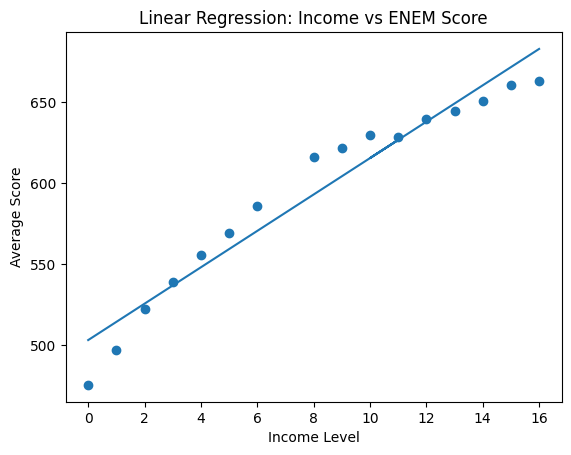

R²: 0.941472740190251


In [5]:
correlacao = df_renda["renda_num"].corr(df_renda["nota_media"])
print('Correlação entre renda e nota média:', correlacao)

df_modelo = df_renda.dropna(subset=["renda_num", "nota_media"])
X = df_modelo[["renda_num"]]
y = df_modelo["nota_media"]
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X, y)
y_pred = modelo.predict(X)
print('slop:',modelo.coef_)
print('intercepto:',modelo.intercept_)

import matplotlib.pyplot as plt

plt.scatter(df_modelo["renda_num"],
            df_modelo["nota_media"])

plt.plot(df_modelo["renda_num"],
         y_pred)

plt.xlabel("Income Level")
plt.ylabel("Average Score")
plt.title("Linear Regression: Income vs ENEM Score")

plt.show()
print('R²:',modelo.score(X, y))

Here it is clear that there is a strong relationship between income and performance. A correlation of approximately 0.97 suggests a strong dependency between the two variables. The slope of 11.2 means that for each one-level increase in income, a student’s average score increases by approximately 11.2 points. Additionally, an R² of 0.94 suggests that 94% of the variation in scores is explained by income, meaning that income is a very strong predictor of a student’s performance.

Let’s analyze some other statistics.

In [6]:
df= df[df["nota_media"] > 0]
estatisticas = df.groupby("renda")["nota_media"].agg(
    media="mean",
    mediana="median",
    desvio_padrao="std",
    minimo="min",
    maximo="max",
    quantidade="count"
).round(2).sort_values(by="media", ascending=False)


estatisticas

,media,mediana,desvio_padrao,minimo,maximo,quantidade
renda,,,,,,
"Acima de R$ 20.900,00",662.80,676.71,84.36,378.23,844.30,704
"De R$ 15.675,01 até R$ 20.900,00",661.74,668.96,77.98,391.66,824.24,589
"De R$ 12.540,01 até R$ 15.675,00",650.48,660.60,81.21,379.73,822.90,567
"De R$ 10.450,01 até R$ 12.540,00",644.24,657.68,86.82,109.47,829.08,581
"De R$ 9.405,01 até R$ 10.450,00",639.33,650.28,85.26,203.06,818.38,676
"De R$ 7.315,01 até R$ 8.360,00",630.88,641.87,85.97,319.22,822.60,627
"De R$ 8.360,01 até R$ 9.405,00",628.22,632.63,87.90,307.17,813.28,508
"De R$ 6.270,01 até R$ 7.315,00",621.51,629.86,86.14,247.88,841.90,816
"De R$ 5.225,01 até R$ 6.270,00",616.33,626.38,91.27,237.37,823.90,1311


# Conclusion

The statistical analysis by income bracket reveals a strong positive correlation between family income and ENEM performance.

A progressive increase in average scores is observed as income rises. Participants in the lowest income brackets show significantly lower performance compared to those in higher-income groups.

Students with no declared income presented an overall average score of 475.85, while those with family income up to R$ 1,045.00 obtained an average of 496.98.

In contrast, students in the highest income bracket (above R$ 20,900.00) achieved an average score of 661.74, the highest among all analyzed groups.

The difference between the income extremes is approximately 164 points, indicating a strong influence of socioeconomic conditions on academic performance.